# Notebook 4: Clause Detection Models

This notebook builds MeridianIQ's first clause detection layer.

The goal is to evaluate whether machine learning models can detect important legal clause categories from contract evidence text.
We compare a traditional TF-IDF baseline against a semantic Sentence Transformer approach to understand which representation works better for this specific legal clause detection task.

##Importing Libraries and Processed Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib,os,re
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,classification_report


pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)

In [ ]:
fingerprints=pd.read_csv("mvp_contract_fingerprints.csv")
risk_config=pd.read_csv("clause_risk_config.csv")
clause_contexts=pd.read_csv("clause_contexts.csv")

fingerprints.shape,risk_config.shape,clause_contexts.shape

((510, 37), (33, 11), (6702, 3))

In [ ]:
mvp_config=risk_config[risk_config["is_mvp_clause"]==True].copy()
mvp_clause_names=mvp_config["clause_name"].to_list()

mvp_contexts=clause_contexts[
    clause_contexts["clause_name"].isin(mvp_clause_names)
].copy()

contract_text_df=(
    mvp_contexts
    .groupby('filename')["context_text"]
    .apply(lambda texts:" ".join(texts.astype(str)))
    .reset_index()
    .rename(columns={"context_text":"contract_evidence_text"})
)

contract_text_df.shape

(462, 2)

In [ ]:
model_df=fingerprints.merge(
    contract_text_df,
    on="filename",
    how="left"

)

model_df["contract_evidence_text"]=model_df["contract_evidence_text"].fillna("")
model_df.shape

(510, 38)

In [ ]:
def to_snake_case(text):
    text =text.lower()
    text =text.replace("/", "_")
    text =text.replace("-", "_")
    text =text.replace(" ", "_")
    text =re.sub(r"[^a-z0-9_]", "",text)
    text =re.sub(r"_+", "_",text)
    return text.strip("_")

In [ ]:
label_cols=[to_snake_case(clause) for clause in mvp_clause_names]

x=model_df["contract_evidence_text"]
y=model_df[label_cols].astype(int)

x.shape,y.shape

((510,), (510, 23))

##Train-Test Split

The dataset is divided into training and testing sets.

Using a fixed random state ensures that both the TF-IDF model and Sentence Transformer model are evaluated on the same test data.

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape


((408,), (102,), (408, 23), (102, 23))

##Visualizing Label Support

Before training models, we inspect how many positive examples exist for each MVP clause.

Understanding label support helps explain why some clauses are easier to detect than others and why accuracy alone is not a reliable metric for this task.

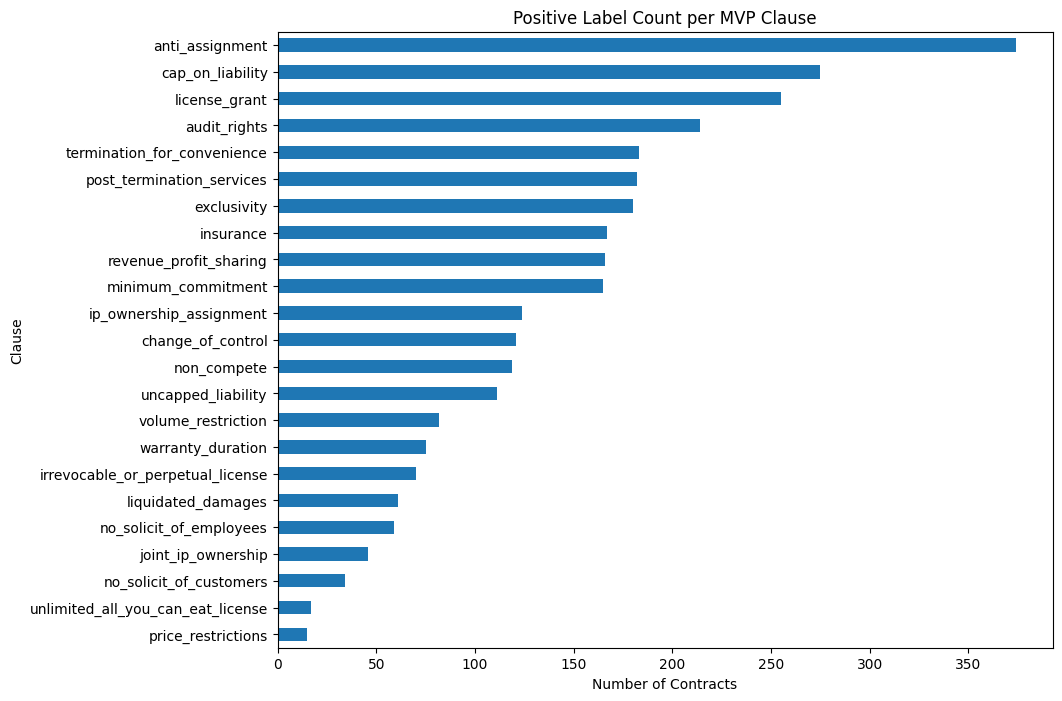

In [ ]:
label_support=y.sum().sort_values(ascending=True)
plt.figure(figsize=(10,8))
label_support.plot(kind="barh")
plt.title("Positive Label Count per MVP Clause")
plt.xlabel("Number of Contracts")
plt.ylabel("Clause")
plt.tight_layout
plt.show()

##TF-IDF + Logistic Regression Baseline

The first model uses TF-IDF features with a One-vs-Rest Logistic Regression classifier.

TF-IDF is a strong baseline for legal text because contracts often contain repeated legal phrases and domain-specific wording.

Logistic Regression is used because it is interpretable, efficient, and works well for high-dimensional sparse text features.

This baseline establishes a simple but reliable reference point before using more advanced semantic representations.

In [ ]:
tfidf=TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

x_train_tfidf=tfidf.fit_transform(x_train)
x_test_tfidf=tfidf.transform(x_test)

In [ ]:
baseline_model=OneVsRestClassifier(
    LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        solver="liblinear"
    )
)

baseline_model.fit(x_train_tfidf,y_train)

OneVsRestClassifier(estimator=LogisticRegression(class_weight='balanced',
                                                 max_iter=1000,
                                                 solver='liblinear'))

In [ ]:
y_pred=baseline_model.predict(x_test_tfidf)

##Evaluating the TF-IDF Baseline

The TF-IDF model is evaluated using precision, recall, and F1-score.

For MeridianIQ, F1-score is more meaningful than accuracy because the task is multi-label and imbalanced.

A model that simply predicts common clauses well may still fail on rare but important clauses, so per-clause evaluation is necessary.

In [ ]:
micro_f1 =f1_score(y_test, y_pred, average="micro", zero_division=0)
macro_f1 =f1_score(y_test, y_pred, average="macro", zero_division=0)
micro_precision =precision_score(y_test, y_pred, average="micro", zero_division=0)
micro_recall =recall_score(y_test, y_pred, average="micro", zero_division=0)

print("Micro Precision:", micro_precision)
print("Micro Recall:", micro_recall)
print("Micro F1:", micro_f1)
print("Macro F1:", macro_f1)


Micro Precision: 0.6255980861244019
Micro Recall: 0.8573770491803279
Micro F1: 0.7233748271092669
Macro F1: 0.6158425162122179
0.19607843137254902


##Per-Clause TF-IDF Performance

This step calculates precision, recall, F1-score, and support for every MVP clause.

Per-clause metrics help us understand where the model performs well and where it struggles.

In [ ]:
per_clause_report = []

for i, col in enumerate(label_cols):
    per_clause_report.append({
        "clause": col,
        "precision": precision_score(y_test.iloc[:, i], y_pred[:, i], zero_division=0),
        "recall": recall_score(y_test.iloc[:, i], y_pred[:, i], zero_division=0),
        "f1": f1_score(y_test.iloc[:, i], y_pred[:, i], zero_division=0),
        "support": int(y_test.iloc[:, i].sum())
    })

per_clause_metrics = pd.DataFrame(per_clause_report).sort_values("f1", ascending=False)
per_clause_metrics

,clause,precision,recall,f1,support
6,anti_assignment,0.876543,0.946667,0.910256,75
22,insurance,0.818182,0.947368,0.878049,38
13,license_grant,0.789474,0.900000,0.841121,50
17,audit_rights,0.741935,0.958333,0.836364,48
19,cap_on_liability,0.727273,0.941176,0.820513,51
7,revenue_profit_sharing,0.702128,0.825000,0.758621,40
15,irrevocable_or_perpetual_license,0.636364,0.933333,0.756757,15
5,change_of_control,0.642857,0.870968,0.739726,31
16,post_termination_services,0.629630,0.894737,0.739130,38
1,exclusivity,0.576923,0.937500,0.714286,32


##Visualizing TF-IDF Clause Performance

The TF-IDF per-clause F1 plot makes model performance easier to interpret.

Instead of only looking at a metrics table, this visualization shows which clauses are detected strongly and which clauses may require improvement in future versions.

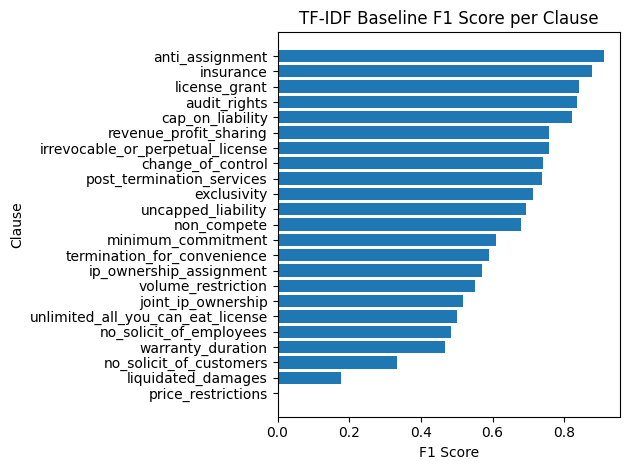

In [ ]:
tfidf_plot=per_clause_metrics.sort_values("f1",ascending=True)
plt.barh(tfidf_plot["clause"], tfidf_plot["f1"])
plt.title("TF-IDF Baseline F1 Score per Clause")
plt.xlabel("F1 Score")
plt.ylabel("Clause")
plt.tight_layout()
plt.show()

##Sentence Transformer Baseline

The second model uses Sentence Transformer embeddings instead of TF-IDF features.

Sentence Transformers convert text into dense semantic vectors, allowing the model to capture meaning beyond exact word overlap.

This approach is tested because legal clauses can sometimes express the same idea using different wording.

In [ ]:
!pip install -U sentence-transformers
from sentence_transformers import SentenceTransformer

embedding_model=SentenceTransformer("all-MiniLM-L6-v2")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.4/596.4 kB 18.5 MB/s eta 0:00:00
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.5.1
    Uninstalling sentence-transformers-5.5.1:
      Successfully uninstalled sentence-transformers-5.5.1


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
x_train_embeddings=embedding_model.encode(
    x_train.tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

x_test_embeddings=embedding_model.encode(
    x_test.tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

x_train_embeddings.shape,x_test_embeddings.shape

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

((408, 384), (102, 384))

##Training the Semantic Clause Detector

A One-vs-Rest Logistic Regression classifier is trained on the Sentence Transformer embeddings.

This keeps the classifier architecture consistent with the TF-IDF baseline while changing only the text representation.

By doing this, the comparison focuses on the value of the feature representation rather than changes in the classifier itself.

In [ ]:
semantic_model=OneVsRestClassifier(
    LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        solver="liblinear"
    )
)
semantic_model.fit(x_train_embeddings,y_train)

OneVsRestClassifier(estimator=LogisticRegression(class_weight='balanced',
                                                 max_iter=1000,
                                                 solver='liblinear'))

In [ ]:
y_pred=semantic_model.predict(x_test_embeddings)

##Evaluating the Semantic Model

The semantic model is evaluated using the same metrics used for the TF-IDF baseline.

In [ ]:
micro_precision = precision_score(y_test, y_pred, average="micro", zero_division=0)
micro_recall = recall_score(y_test, y_pred, average="micro", zero_division=0)
micro_f1 = f1_score(y_test, y_pred, average="micro", zero_division=0)
macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print("Micro Precision:", micro_precision)
print("Micro Recall:", micro_recall)
print("Micro F1:", micro_f1)
print("Macro F1:", macro_f1)

Micro Precision: 0.5422374429223744
Micro Recall: 0.7786885245901639
Micro F1: 0.639300134589502
Macro F1: 0.5319102994757724


##Per-Clause Sentence Transformer Performance

This step calculates per-clause performance for the semantic model.

In [ ]:
semantic_report=[]
for i, col in enumerate(label_cols):
    semantic_report.append({
        "clause": col,
        "precision": precision_score(y_test.iloc[:, i], y_pred[:, i], zero_division=0),
        "recall": recall_score(y_test.iloc[:, i], y_pred[:, i], zero_division=0),
        "f1": f1_score(y_test.iloc[:, i], y_pred[:, i], zero_division=0),
        "support": int(y_test.iloc[:, i].sum())
    })

semantic_metrics = pd.DataFrame(semantic_report).sort_values("f1", ascending=False)

semantic_metrics

,clause,precision,recall,f1,support
6,anti_assignment,0.900000,0.960000,0.929032,75
13,license_grant,0.814815,0.880000,0.846154,50
19,cap_on_liability,0.707692,0.901961,0.793103,51
17,audit_rights,0.661290,0.854167,0.745455,48
4,termination_for_convenience,0.658537,0.843750,0.739726,32
7,revenue_profit_sharing,0.692308,0.675000,0.683544,40
1,exclusivity,0.577778,0.812500,0.675325,32
5,change_of_control,0.585366,0.774194,0.666667,31
16,post_termination_services,0.524590,0.842105,0.646465,38
9,minimum_commitment,0.552632,0.700000,0.617647,30


##Visualizing Sentence Transformer Performance

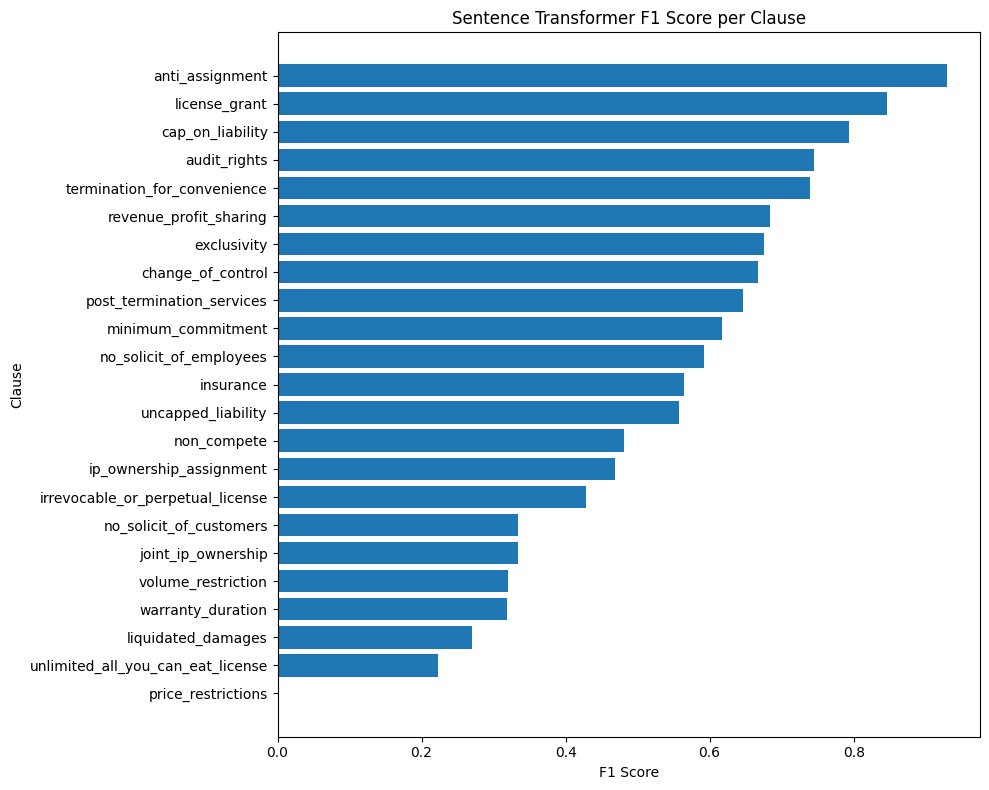

In [ ]:
semantic_plot = semantic_metrics.sort_values("f1", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(semantic_plot["clause"], semantic_plot["f1"])
plt.title("Sentence Transformer F1 Score per Clause")
plt.xlabel("F1 Score")
plt.ylabel("Clause")
plt.tight_layout()
plt.show()

##Saving Baseline Metrics

In [ ]:
per_clause_metrics.to_csv("baseline_extraction_metrics.csv",index=False)
baseline_metrics=pd.read_csv("baseline_extraction_metrics.csv")

##Comparing TF-IDF and Sentence Transformer Models

This step merges the TF-IDF metrics and Sentence Transformer metrics into a single comparison table.

The comparison calculates differences in F1-score and recall between both approaches.

In [ ]:
comparison = baseline_metrics.merge(
    semantic_metrics,
    on="clause",
    how="outer",
    suffixes=("_baseline", "_semantic")
)

comparison["f1_delta"] = comparison["f1_semantic"] - comparison["f1_baseline"]
comparison["recall_delta"] = comparison["recall_semantic"] - comparison["recall_baseline"]

comparison.sort_values("f1_delta", ascending=False)

,clause,precision_baseline,recall_baseline,f1_baseline,support_baseline,precision_semantic,recall_semantic,f1_semantic,support_semantic,f1_delta,recall_delta
18,termination_for_convenience,0.500000,0.718750,0.589744,32,0.658537,0.843750,0.739726,32,0.149982,0.125000
13,no_solicit_of_employees,0.368421,0.700000,0.482759,10,0.470588,0.800000,0.592593,10,0.109834,0.100000
10,liquidated_damages,0.111111,0.428571,0.176471,7,0.166667,0.714286,0.270270,7,0.093800,0.285714
0,anti_assignment,0.876543,0.946667,0.910256,75,0.900000,0.960000,0.929032,75,0.018776,0.013333
11,minimum_commitment,0.480769,0.833333,0.609756,30,0.552632,0.700000,0.617647,30,0.007891,-0.133333
9,license_grant,0.789474,0.900000,0.841121,50,0.814815,0.880000,0.846154,50,0.005032,-0.020000
12,no_solicit_of_customers,0.285714,0.400000,0.333333,5,0.230769,0.600000,0.333333,5,0.000000,0.200000
16,price_restrictions,0.000000,0.000000,0.000000,1,0.000000,0.000000,0.000000,1,0.000000,0.000000
2,cap_on_liability,0.727273,0.941176,0.820513,51,0.707692,0.901961,0.793103,51,-0.027409,-0.039216
4,exclusivity,0.576923,0.937500,0.714286,32,0.577778,0.812500,0.675325,32,-0.038961,-0.125000


##Visual Model Comparison

The side-by-side comparison plot shows TF-IDF and Sentence Transformer F1-scores for each clause.

This visualization makes the model selection decision easier to understand.

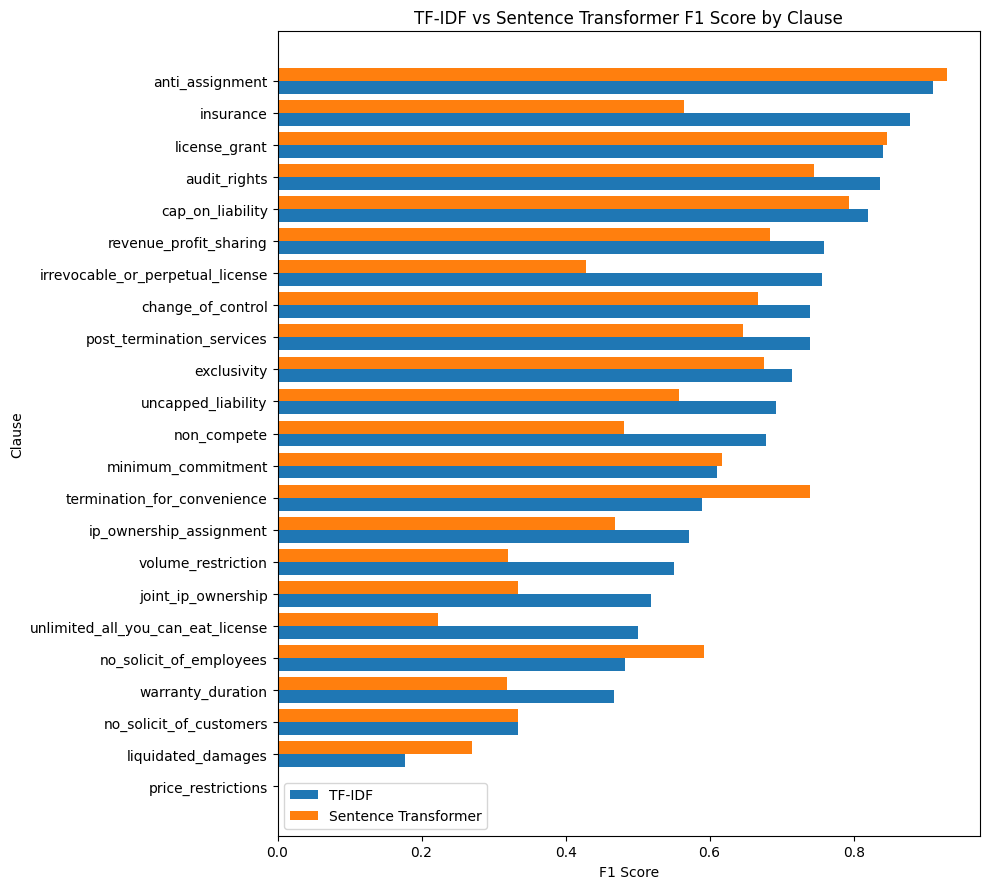

In [ ]:
comparison_plot = comparison.sort_values("f1_baseline", ascending=True)

plt.figure(figsize=(10, 9))

y_pos = np.arange(len(comparison_plot))
bar_width = 0.4

plt.barh(
    y_pos - bar_width/2,
    comparison_plot["f1_baseline"],
    height=bar_width,
    label="TF-IDF"
)

plt.barh(
    y_pos + bar_width/2,
    comparison_plot["f1_semantic"],
    height=bar_width,
    label="Sentence Transformer"
)

plt.yticks(y_pos, comparison_plot["clause"])
plt.xlabel("F1 Score")
plt.ylabel("Clause")
plt.title("TF-IDF vs Sentence Transformer F1 Score by Clause")
plt.legend()
plt.tight_layout()
plt.show()

##F1 Delta Analysis

The F1 delta plot shows where Sentence Transformers improved over TF-IDF and where TF-IDF performed better.

The goal is not to force the most advanced model into production, but to understand which technique is best suited for each part of the system.

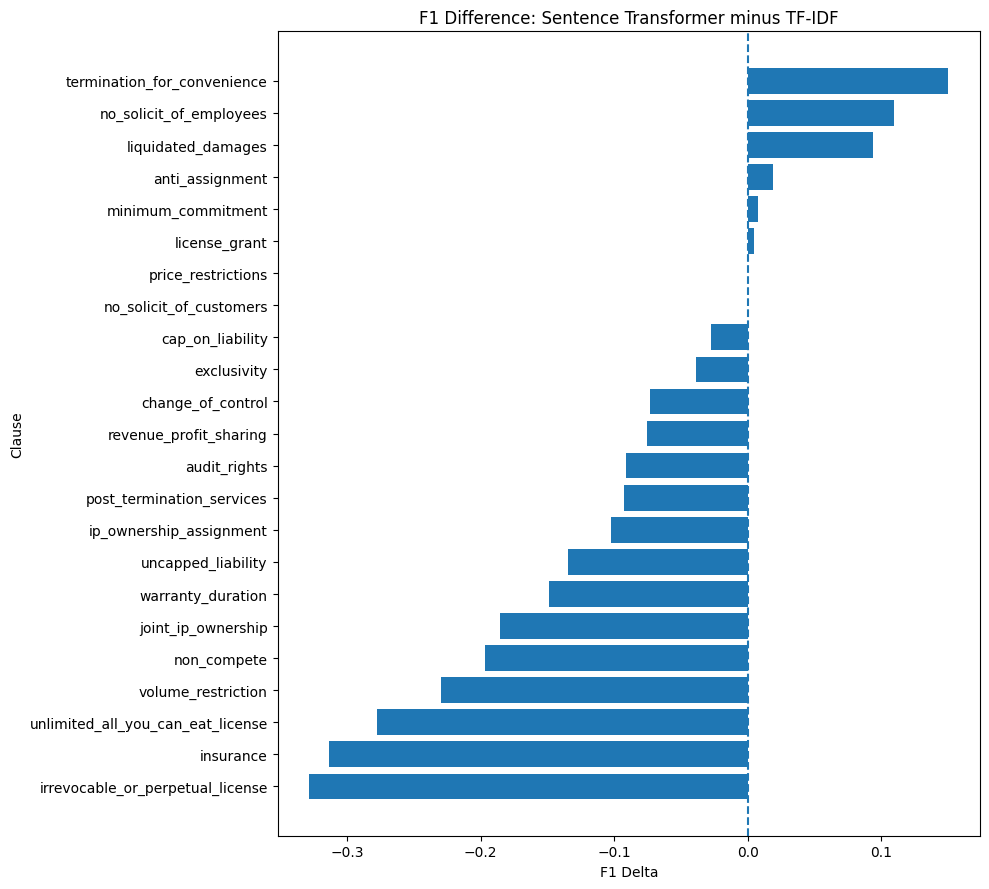

In [ ]:
delta_plot = comparison.sort_values("f1_delta", ascending=True)

plt.figure(figsize=(10, 9))
plt.barh(delta_plot["clause"], delta_plot["f1_delta"])
plt.axvline(0, linestyle="--")
plt.title("F1 Difference: Sentence Transformer minus TF-IDF")
plt.xlabel("F1 Delta")
plt.ylabel("Clause")
plt.tight_layout()
plt.show()

##Saving Trained Models and Reports

In [ ]:
joblib.dump(tfidf,"tfidf_vectorizer.pkl")
joblib.dump(baseline_model,"baseline_clause_detector.pkl")
joblib.dump(semantic_model,"semantic_clause_detector.pkl")

per_clause_metrics.to_csv("baseline_extraction_metrics.csv",index=False)
semantic_metrics.to_csv("semantic_extraction_metrics.csv",index=False)
comparison.to_csv("baseline_vs_semantic_comparison.csv",index=False)


##Notebook Summary

This notebook built and compared two clause detection approaches for MeridianIQ:

TF-IDF + Logistic Regression
Sentence Transformer embeddings + Logistic Regression

The TF-IDF approach performed better overall for clause detection in this controlled setup, likely because legal contracts contain repeated domain-specific phrases and the dataset size is relatively limited.

However, Sentence Transformers remain valuable for semantic retrieval and evidence search, which is why MeridianIQ uses them in the retrieval layer rather than forcing them to be the primary classifier.

This notebook establishes MeridianIQ's hybrid modeling strategy:

1. TF-IDF for reliable clause detection
2. Sentence Transformers for semantic evidence retrieval
3. Risk Engine for business interpretation
4. LLM Orchestration for executive reporting